 **Task 6: House Price Prediction**

 Intern: Muhammad Zoraiz Khan

 Organization: DevelopersHub Corporation



Dataset loaded. Shape: (20000, 9)


,Size,Number of rooms,Location,Distance of the center,Years of construction,Date,Country,Build quality,Price final
0,0.935726,0.921034,0.050417,0.173085,0.139500,12/09/1995,Ghana,7,643428
1,0.945854,0.084170,0.211671,0.080723,0.980385,17/06/2015,Christmas Island,4,939085
2,0.425973,0.190178,0.221490,0.443040,0.768223,22/10/2001,Cocos (Keeling) Islands,8,149126
3,0.599944,0.237729,0.584219,0.387131,0.034368,05/04/2008,South Georgia and the South Sandwich Islands,5,951468
4,0.293112,0.322832,0.065941,0.615047,0.849242,15/12/1997,Niger,7,357705


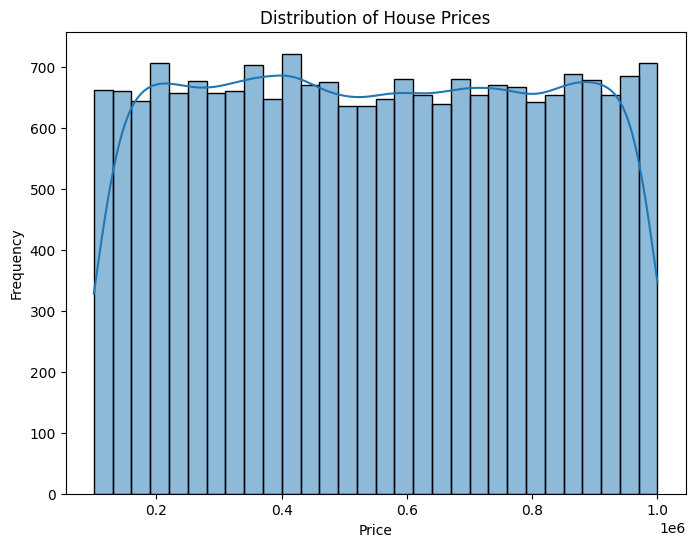

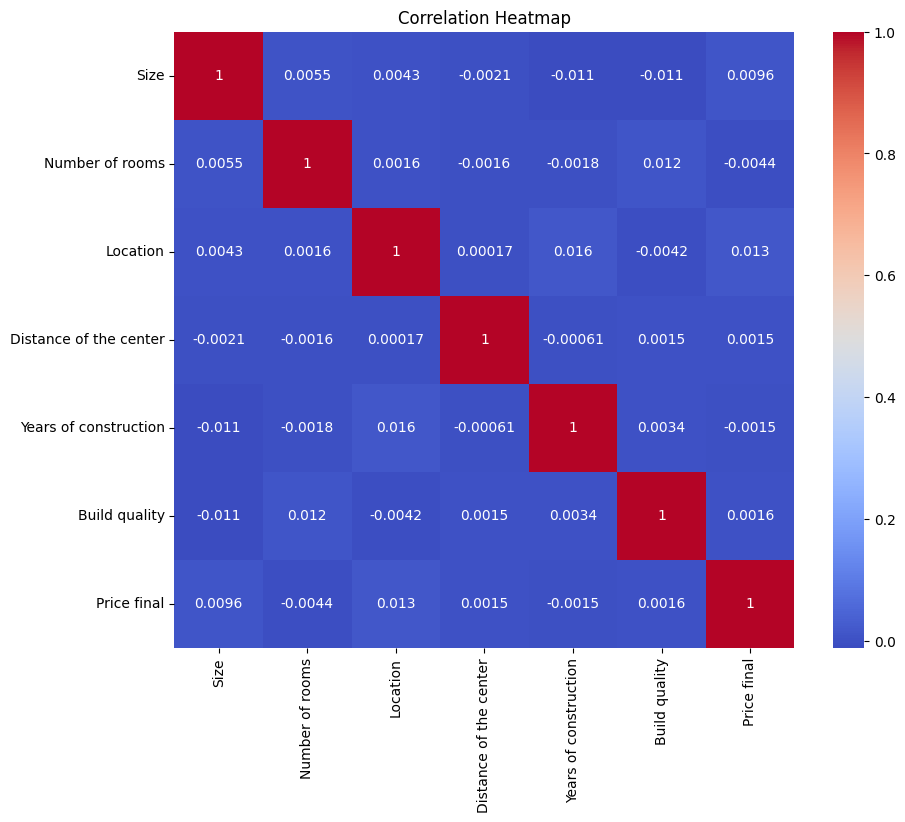

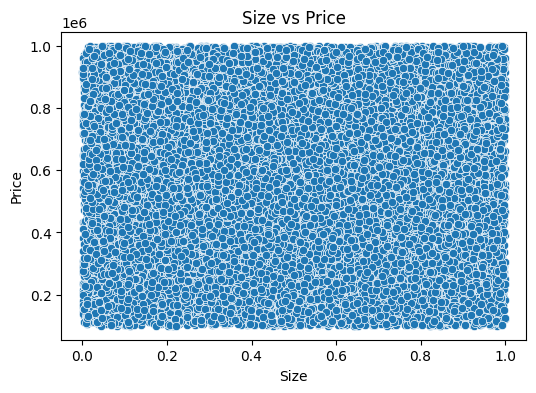

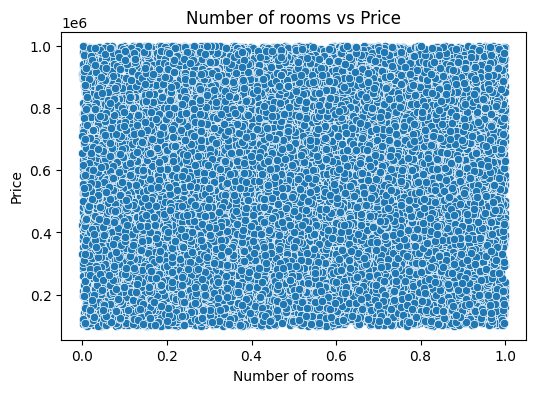

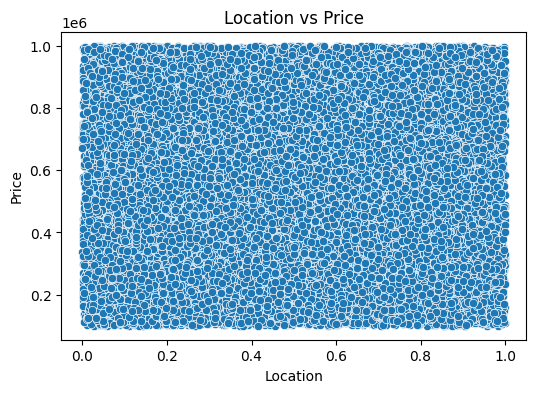


Model Performance
--------------------------------------------------
Linear Regression MAE  : 266162.17
Linear Regression RMSE : 324665.98
--------------------------------------------------
Gradient Boosting MAE  : 223628.61
Gradient Boosting RMSE : 258581.43


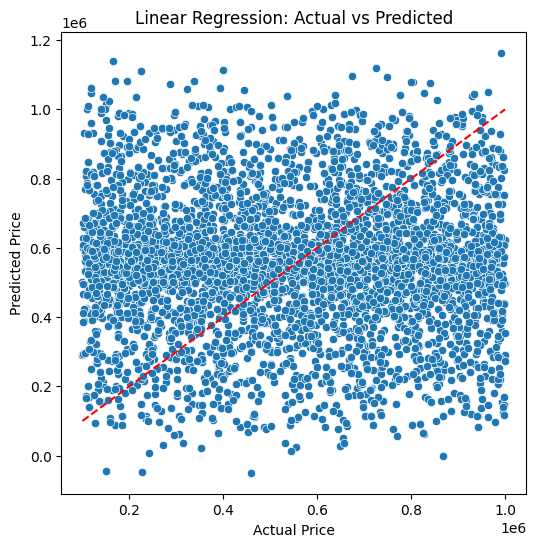

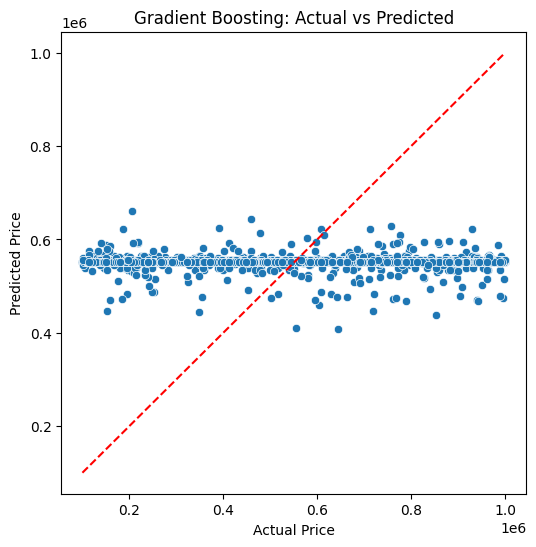

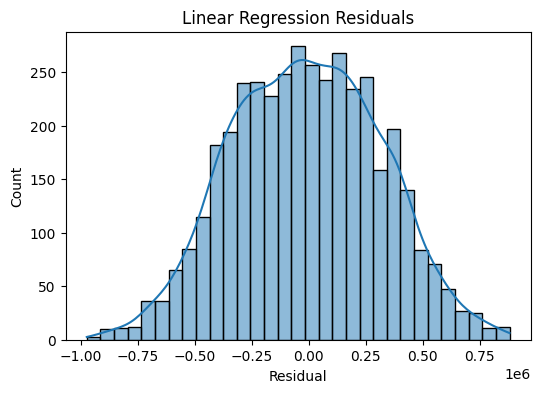

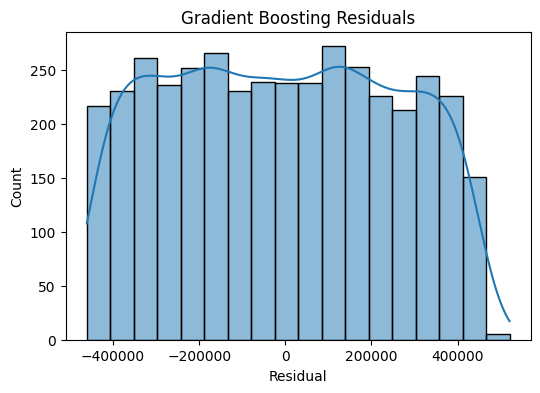

In [1]:

# House Price Prediction Using Public Dataset (Prices house.csv)
# Dataset source: https://huggingface.co/Tahani1/Houses-Prices-Prediction/resolve/main/Prices%20house.csv


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ============================================================
# Load dataset from raw URL
# ============================================================
url = "https://huggingface.co/Tahani1/Houses-Prices-Prediction/resolve/main/Prices%20house.csv"
df = pd.read_csv(url)

print("Dataset loaded. Shape:", df.shape)
display(df.head())

# Data cleaning

df = df.drop_duplicates()
df = df.dropna()  # drop rows with missing values

# Rename target column if necessary
if "price" in df.columns:
    target = "price"
else:
    target = df.columns[-1]  # use last column as target if price not found

X = df.drop(columns=[target])
y = df[target]

# Identify numeric and categorical features
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

# Exploratory Visualizations
plt.figure(figsize=(8,6))
sns.histplot(y, bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Scatter plots for first numeric features
for col in numeric_features[:3]:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[col], y=y)
    plt.title(f"{col} vs Price")
    plt.xlabel(col)
    plt.ylabel("Price")
    plt.show()

# Preprocessing pipeline

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Train-test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression model

lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
lr_preds = lr_pipeline.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))

# Gradient Boosting model

gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

gb_pipeline.fit(X_train, y_train)
gb_preds = gb_pipeline.predict(X_test)

gb_mae = mean_absolute_error(y_test, gb_preds)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_preds))

# Print performance

print("\nModel Performance")
print("--------------------------------------------------")
print(f"Linear Regression MAE  : {lr_mae:.2f}")
print(f"Linear Regression RMSE : {lr_rmse:.2f}")
print("--------------------------------------------------")
print(f"Gradient Boosting MAE  : {gb_mae:.2f}")
print(f"Gradient Boosting RMSE : {gb_rmse:.2f}")

# Visualization: Actual vs Predicted

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=lr_preds)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.title("Linear Regression: Actual vs Predicted")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=gb_preds)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.title("Gradient Boosting: Actual vs Predicted")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

# Residual analysis

residuals_lr = y_test - lr_preds
residuals_gb = y_test - gb_preds

plt.figure(figsize=(6,4))
sns.histplot(residuals_lr, kde=True)
plt.title("Linear Regression Residuals")
plt.xlabel("Residual")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(residuals_gb, kde=True)
plt.title("Gradient Boosting Residuals")
plt.xlabel("Residual")
plt.show()

## Preprocessing Steps in the Pipeline

The notebook preprocesses the data to prepare it for model training using a `ColumnTransformer` within a `Pipeline`. Here's a breakdown of the steps:

1.  **Identify Feature Types**: The code first separates features into `numeric_features` (e.g., `int64`, `float64`) and `categorical_features` (e.g., `object`).

2.  **Numeric Preprocessing (StandardScaler)**: For all `numeric_features`, a `StandardScaler` is applied. This scales each numeric feature independently to have a mean of 0 and a standard deviation of 1. This is crucial for many machine learning algorithms that are sensitive to the scale of input features.

3.  **Categorical Preprocessing (OneHotEncoder)**: For `categorical_features`, a `OneHotEncoder` is used. This converts categorical variables into a format that can be provided to machine learning algorithms. Each unique category in a feature is transformed into a new binary column (0 or 1). The `handle_unknown='ignore'` parameter ensures that if a new, unseen category appears during prediction, it won't cause an error.

4.  **ColumnTransformer**: Both these transformers (`StandardScaler` and `OneHotEncoder`) are combined into a `ColumnTransformer`. This allows different preprocessing steps to be applied to different columns of the DataFrame simultaneously, ensuring that the correct transformations are applied to the appropriate feature types.